In [1]:
import k_fail_MBTR
import BB_wrapper
import k_fail_prediction

import torch

/Users/karim/projects/k-sPSS/.venv/lib/python3.11/site-packages/pycutest/__init__.py:26: RuntimeWarning: the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.
  warnings.warn("the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.", RuntimeWarning)


# Wrapper

In [2]:
cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="cutest_problem_selection.txt", max_dim=100, cap_n_problems=1)

loading problems...
0/276
loaded 1 problems


In [3]:
# evaluating n problem functions
for i in range(1):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"{p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

SISSER | n: 2: 3.02030030003


# MBTR

In [4]:
problem_idx = 0
k = 2
k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), 8)

alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), k_fail_wrapper, 1, 1e-1, 0.1, 0.5, 1e-1, k_fail_prediction.constant_prediction_software(k), log_file_path="alg_logs/MBTR/testing_simplex_hess.txt", preferred_model_order=2)

In [5]:
alg.log_current()
for i in range(1000):
    if alg.step_default():
        break


# is n + 2k + 1 fair?
# with it, always linear: 1847 function evals
# with always quad: 448 function evals

In [6]:
# H: None
# points: [[ 0.          0.        ]
#  [-0.15244442  0.4307067 ]
#  [-0.05507779  0.22729501]
#  [-0.39858192  0.6989344 ]
#  [-0.04768276  0.20510971]
#  [-0.0833317   0.29964896]]

# fixed version (still breaks)
# H: None
# points: [[0.         0.        ]
#  [0.21817741 0.44988734]
#  [0.45346695 0.21063653]
#  [0.45938012 0.19740793]
#  [0.41485953 0.27909064]
#  [0.49603891 0.06281256]]


broken_x_k = torch.tensor([1.0000, 0.1000])
broken_points = torch.tensor([
 [0.        , 0.        ],
 [0.21817741, 0.44988734],
 [0.45346695, 0.21063653],
 [0.45938012, 0.19740793],
 [0.41485953, 0.27909064],
 [0.49603891, 0.06281256]])

broken_func_vals = []

for p in broken_points:
    print(p, " | ", cutest_wrapper.problem_functions[0](p + broken_x_k))
    broken_func_vals.append(cutest_wrapper.problem_functions[0](p + broken_x_k))

broken_func_vals = torch.tensor(broken_func_vals)


tensor([0., 0.])  |  3.0203003006439277
tensor([0.2182, 0.4499])  |  7.77809909471623
tensor([0.4535, 0.2106])  |  13.824444939862795
tensor([0.4594, 0.1974])  |  14.008260278544622
tensor([0.4149, 0.2791])  |  12.659262761617814
tensor([0.4960, 0.0628])  |  15.148476370717711


In [4]:
# testing if the model is broken
import models
import torch

points = torch.tensor([
    [-1],
    [0],
    [1]
], dtype=torch.float64)

f_vals = torch.tensor([
    1,
    0,
    1
], dtype=torch.float64)

delta = 2

points.shape

torch.Size([3, 1])

In [5]:
models.get_quad_model_and_solution(points, f_vals, delta)

GOT: tensor([[-1.],
        [ 0.],
        [ 1.]], dtype=torch.float64)
TRIMMED: tensor([[-1.],
        [ 0.],
        [ 1.]], dtype=torch.float64)
trimmed func_values tensor([1., 0., 1.], dtype=torch.float64)
RELATIVE POINTS [[0.]
 [1.]
 [2.]]
points dtype: float64
func_values dtype: float64
points type: <class 'numpy.ndarray'>
func_values type: <class 'numpy.ndarray'>
n: 1
HESSIAN [[2.]]


(tensor([0.], dtype=torch.float64),
 array([0.]),
 tensor([-2.], dtype=torch.float64),
 <function models.get_quad_model_and_solution.<locals>.f_tilda(x)>)

In [6]:
models.get_lin_model_and_solution(points, f_vals, delta)

tensor([[-1.],
        [ 0.],
        [ 1.]], dtype=torch.float64)
tensor([1., 0., 1.], dtype=torch.float64)
D_t_pinv: tensor([[0.2000, 0.4000]], dtype=torch.float64)
delta_f tensor([-1.,  0.], dtype=torch.float64)


(tensor([-0.6000], dtype=torch.float64),
 tensor(0.9200, dtype=torch.float64),
 tensor([-0.2000], dtype=torch.float64),
 <function models.get_lin_model_and_solution.<locals>.f_tilda(x)>)

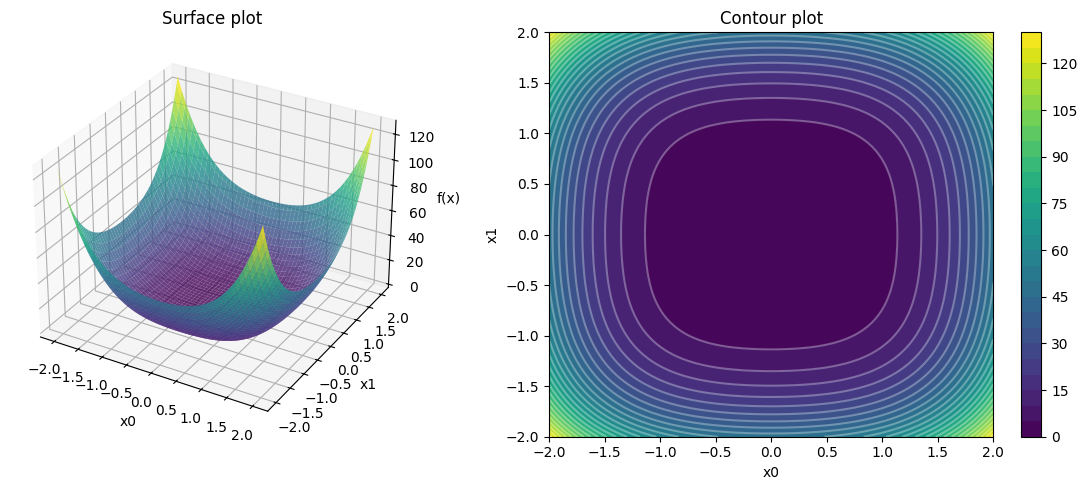

In [21]:
import numpy as np
import matplotlib.pyplot as plt

f = cutest_wrapper.problem_functions[0]

# grid — build in torch
x0_range = torch.linspace(-2, 2, 100)
x1_range = torch.linspace(-2, 2, 100)
X0, X1 = torch.meshgrid(x0_range, x1_range, indexing='ij')
# stack X0 and X1 into a (2, 100, 100) tensor and apply f to each column
X = torch.stack([X0, X1], dim=0).double()  # shape (2, 100, 100)

# apply f to each point on the grid
Z = torch.zeros(100, 100, dtype=torch.float64)
for i in range(100):
    for j in range(100):
        Z[i, j] = f(X[:, i, j])  # passes a tensor of size 2 to f

# convert to numpy for matplotlib
X0 = X0.numpy()
X1 = X1.numpy()
Z  = Z.detach().numpy()  # detach in case f builds a compute graph

# plot
fig = plt.figure(figsize=(12, 5))

# surface
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X0, X1, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x0')
ax.set_ylabel('x1')
ax.set_zlabel('f(x)')
ax.set_title('Surface plot')

# contour
ax2 = fig.add_subplot(122)
cf = ax2.contourf(X0, X1, Z, levels=30, cmap='viridis')
ax2.contour(X0, X1, Z, levels=30, colors='white', alpha=0.3)
ax2.set_xlabel('x0')
ax2.set_ylabel('x1')
ax2.set_title('Contour plot')
plt.colorbar(cf, ax=ax2)

plt.tight_layout()
plt.show()

tensor([[ 0.0839,  0.0826, -0.1193,  ...,  0.0181, -0.0601, -0.1511],
        [-0.0350, -0.1086, -0.0635,  ...,  0.0420, -0.0539, -0.0640],
        [-0.0719, -0.0484, -0.0157,  ...,  0.1586,  0.0320,  0.0823],
        ...,
        [ 0.0547,  0.0444,  0.1468,  ...,  0.0332, -0.1120, -0.0675],
        [-0.1612, -0.1526,  0.1249,  ..., -0.0313,  0.0119, -0.0314],
        [-0.1159,  0.0819,  0.1366,  ...,  0.0209, -0.0134, -0.1457]])


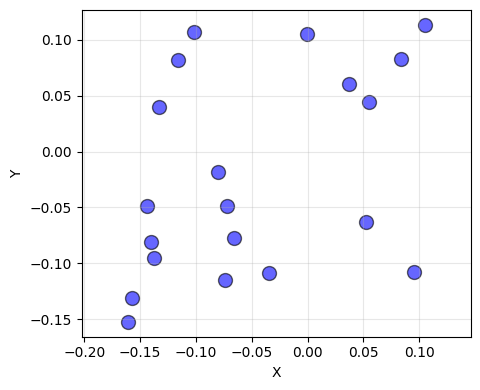

In [2]:
import models
import matplotlib.pyplot as plt

D = models.get_random_D_max_norm_1(20, 100)
print(D)
x_coords = [p[0] for p in D]
y_coords = [p[1] for p in D]

# Create the plot
plt.figure(figsize=(5, 4))
plt.scatter(x_coords, y_coords, s=100, c='blue', alpha=0.6, edgecolors='black')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()

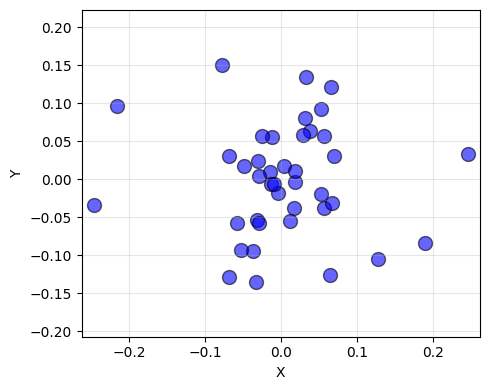

tensor([[ 0.2458,  0.0337, -0.1307,  ...,  0.0326,  0.2381, -0.1430],
        [-0.2462, -0.0338,  0.1309,  ..., -0.0326, -0.2384,  0.1432],
        [ 0.0377,  0.0638,  0.1668,  ...,  0.0395,  0.1840, -0.0163],
        ...,
        [-0.0778,  0.1508,  0.0581,  ..., -0.1128,  0.0252,  0.0440],
        [ 0.0531, -0.0192, -0.0844,  ...,  0.1880, -0.0789,  0.0347],
        [-0.0481,  0.0174,  0.0764,  ..., -0.1703,  0.0715, -0.0315]])

In [1]:
import models
import matplotlib.pyplot as plt

D = models.get_orthogonal_Q_D_max_norm_q(40, 100)
x_coords = [p[0] for p in D]
y_coords = [p[1] for p in D]

# Create the plot
plt.figure(figsize=(5, 4))
plt.scatter(x_coords, y_coords, s=100, c='blue', alpha=0.6, edgecolors='black')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()
D

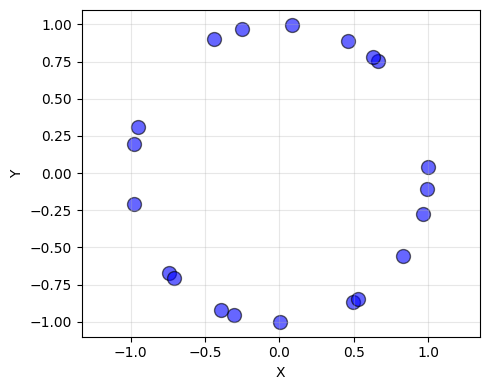

tensor([[ 0.6604,  0.7509],
        [ 0.9992,  0.0397],
        [ 0.4968, -0.8679],
        [ 0.6272,  0.7789],
        [-0.3031, -0.9530],
        [ 0.4634,  0.8862],
        [-0.4384,  0.8988],
        [ 0.0811,  0.9967],
        [ 0.9624, -0.2718],
        [ 0.8290, -0.5592],
        [-0.7403, -0.6722],
        [-0.3943, -0.9190],
        [ 0.0031, -1.0000],
        [-0.9775, -0.2109],
        [-0.9809,  0.1945],
        [-0.9507,  0.3100],
        [ 0.9943, -0.1071],
        [-0.2546,  0.9670],
        [-0.7082, -0.7060],
        [ 0.5286, -0.8489]], dtype=torch.float64)

In [14]:
import models
import matplotlib.pyplot as plt

D = models.get_random_unit_D(20, 2)
x_coords = [p[0] for p in D]
y_coords = [p[1] for p in D]

# Create the plot
plt.figure(figsize=(5, 4))
plt.scatter(x_coords, y_coords, s=100, c='blue', alpha=0.6, edgecolors='black')
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.xlabel('X')
plt.ylabel('Y')
plt.tight_layout()
plt.show()
D

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

def PW(k, cluster):
    P = np.zeros(k + 1)
    for i in range(1, k + 1):
        P[i - 1] = comb(cluster - i, k - i) / comb(cluster, k)
    P[k] = 0

    W = np.zeros(k + 1)
    for i in range(1, k + 2):
        W[i - 1] = i * (1000 - P[i - 1] * 1000) + cluster * P[i - 1] * 1000

    plt.plot(range(1, k + 2), W)
    plt.show()
    return W

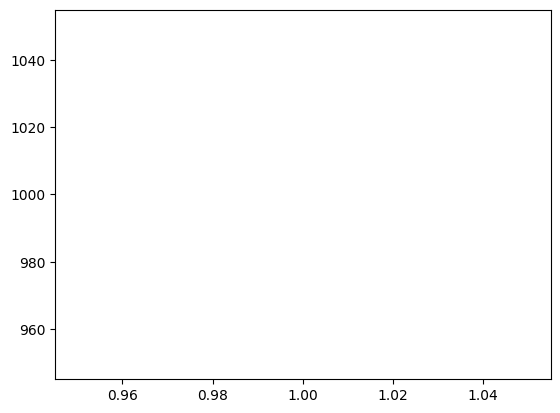

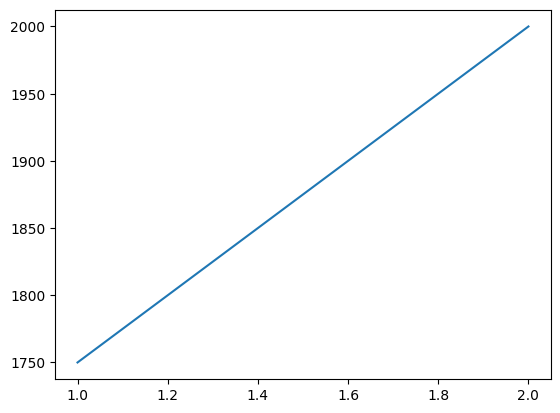

array([1750., 2000.])

In [6]:
PW(0, 4)
PW(1, 4)

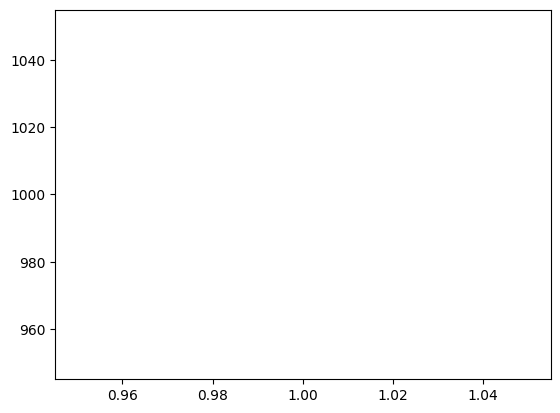

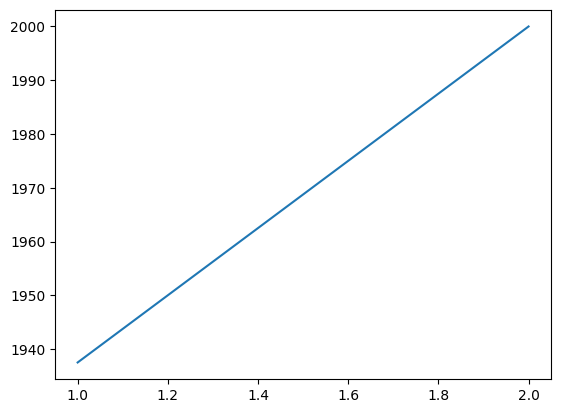

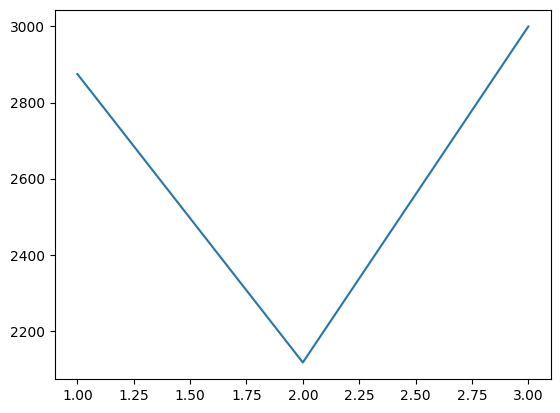

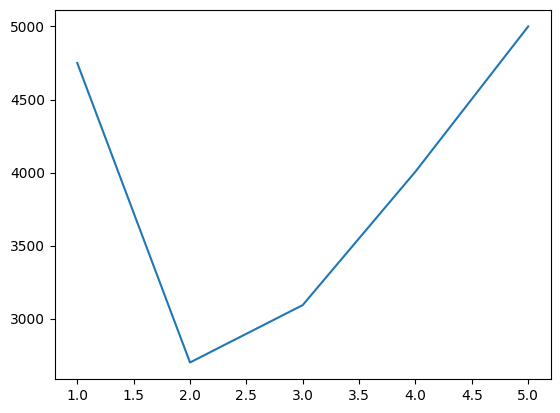

array([4750.        , 2700.        , 3092.85714286, 4006.59340659,
       5000.        ])

In [7]:
PW(0, 16)
PW(1, 16)
PW(2, 16)
PW(4, 16)

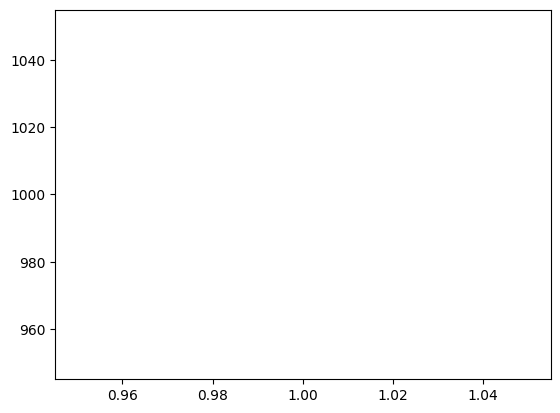

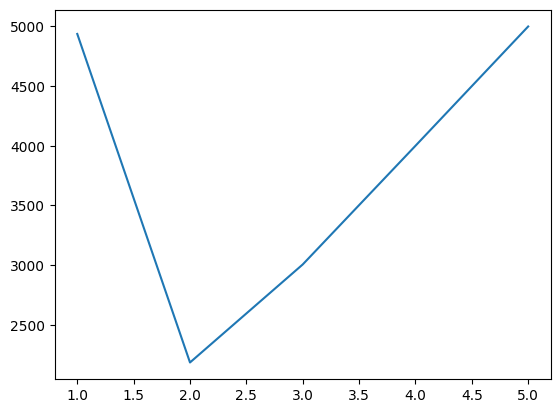

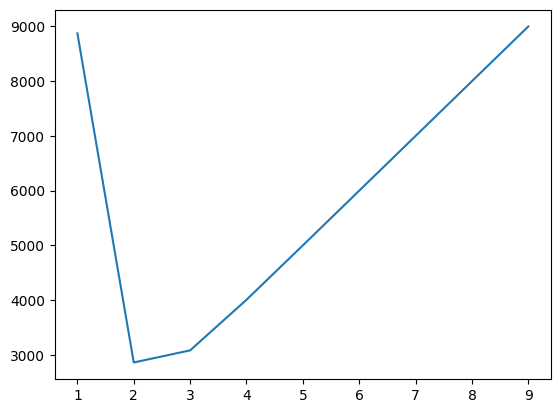

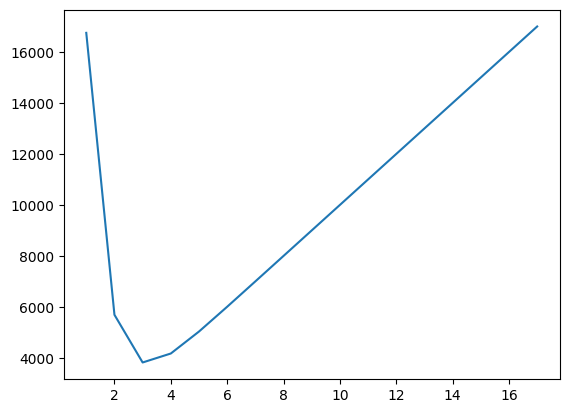

array([16750.        ,  5690.47619048,  3819.89247312,  4171.86673718,
        5033.80045831,  6006.19497053,  7001.04968288,  8000.16283169,
        9000.02284628, 10000.00285484, 11000.00031133, 12000.00002882,
       13000.00000217, 14000.00000013, 15000.        , 16000.        ,
       17000.        ])

In [8]:
PW(0, 64)
PW(4, 64)
PW(8, 64)
PW(16, 64)